# Spatial smoothing

Peter Ralph  
2026-02-27

In class Wednesday we made a smoothed version of the density of bike
trips: [slides](../slides/spatial_smoothing.html).

Today, I’d like you to explore the choice of *bandwidth*. There were
actually two parameters underlying the smoothing: `sigma` and `delta`.
First, explain:

What are these numbers, in words? Are the values we used in the slides
good choices?

Then, explore different choices of these two parameters. To do this:

1.  Write a function that takes in `sigma` and `delta` and makes a plot.
2.  Play around with it.

## The code

For convenience, here’s the code, which uses the [biketown
data](../data/biketown/2018_08_csv.gz).

In [3]:
import pyproj
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import contextily

gdf = pd.read_csv("../data/biketown/2018_08.csv.gz")
gdf = gdf.loc[~gdf['StartLatitude'].isna(),:]
gdf['start_points'] = gpd.points_from_xy(gdf.StartLongitude, gdf.StartLatitude, crs="EPSG:4326").to_crs("EPSG:5070")
gdf['end_points'] = gpd.points_from_xy(gdf.EndLongitude, gdf.EndLatitude, crs="EPSG:4326").to_crs("EPSG:5070")
gdf = gpd.GeoDataFrame(gdf, geometry=gdf['start_points'], crs=5070)

In [4]:
sigma = 500 # meters
delta = 100 # meters
xy = np.array([x.coords[0] for x in gdf['start_points']])
extent = [np.min(xy[:,1]), np.max(xy[:,1]), np.min(xy[:,0]), np.max(xy[:,0])]
xx = np.linspace(extent[2], extent[3], int(abs(extent[3]-extent[2])/delta))
yy = np.linspace(extent[0], extent[1], int(abs(extent[1]-extent[0])/delta))
heatmap, xedges, yedges = np.histogram2d(xy[:,0], xy[:,1], bins=[xx, yy])
heatmap = scipy.ndimage.gaussian_filter(heatmap, sigma=sigma/delta, mode='nearest')

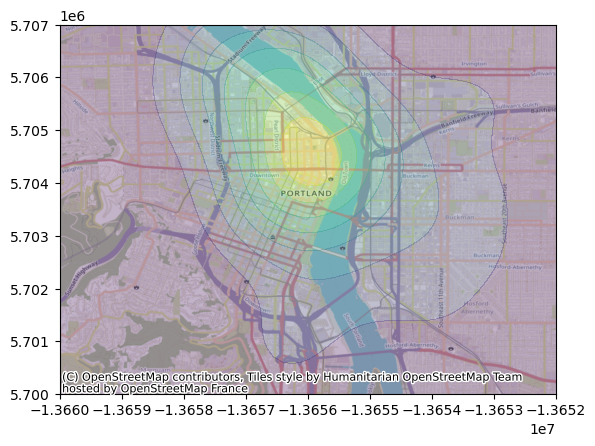

In [5]:
xpts = gpd.points_from_xy(xx, np.full((len(xx),), np.mean(yy)), crs="EPSG:5070").to_crs("EPSG:3857")
ypts = gpd.points_from_xy(np.full((len(yy),), np.mean(xx)), yy, crs="EPSG:5070").to_crs("EPSG:3857")
XX, YY = np.meshgrid(
    [x.coords[0][0] for x in xpts[1:]],
    [y.coords[0][1] for y in ypts[1:]],
)
fig, ax = plt.subplots()
ax.contourf(XX, YY, heatmap.T, alpha=0.3)
ax.set_xlim(-1.366e7, -1.3652e7)
ax.set_ylim(5.7e6, 5.707e6)
# uncomment this:
contextily.add_basemap(ax);